In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

In [12]:
# Task 1: Monte Carlo estimation of pi

N = 100_000

# Generate random points
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

# Check if points are inside the unit circle
inside = x**2 + y**2 <= 1

# Estimate pi
pi_estimate = 4 * np.sum(inside) / N

print(f"Estimated π: {pi_estimate:.5f}")
print(f"True π: {np.pi:.5f}")

Estimated π: 3.14412
True π: 3.14159


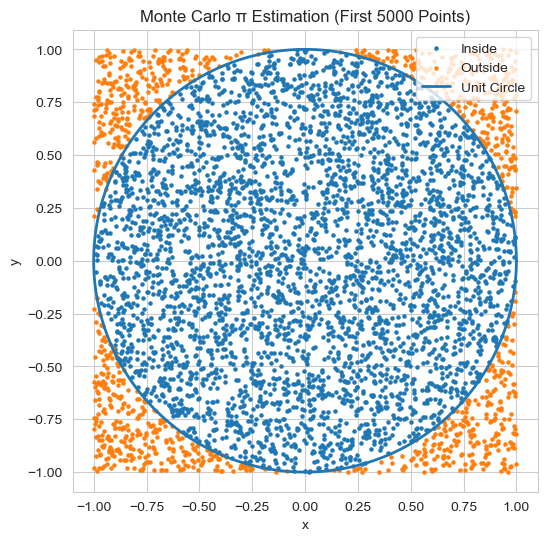

In [13]:
# Scatter plot of first 5000 points
n_plot = 5000

plt.figure(figsize=(6,6))

# Inside points
plt.scatter(x[:n_plot][inside[:n_plot]], 
            y[:n_plot][inside[:n_plot]], 
            s=5, label="Inside")

# Outside points
plt.scatter(x[:n_plot][~inside[:n_plot]], 
            y[:n_plot][~inside[:n_plot]], 
            s=5, label="Outside")

# Draw unit circle
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), linewidth=2, label="Unit Circle")

plt.title("Monte Carlo π Estimation (First 5000 Points)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axis("equal")

plt.show()

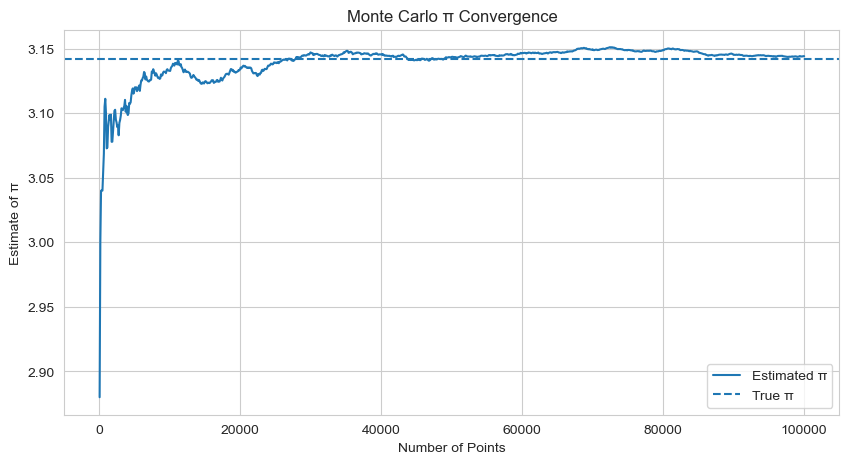

In [14]:
# Running estimate every 100 points
steps = np.arange(100, N+1, 100)
running_pi = []

for n in steps:
    estimate = 4 * np.sum(inside[:n]) / n
    running_pi.append(estimate)

# Plot convergence
plt.figure(figsize=(10,5))
plt.plot(steps, running_pi, label="Estimated π")
plt.axhline(np.pi, linestyle="--", label="True π")

plt.title("Monte Carlo π Convergence")
plt.xlabel("Number of Points")
plt.ylabel("Estimate of π")
plt.legend()

plt.show()

### Task 1: Monte Carlo π Estimation — Observations

- The estimate of π becomes more stable as the number of sampled points increases.
- Initially, the estimate fluctuates significantly due to randomness, but variability decreases over time.

- The estimate typically stabilizes within ±0.01 of the true value of π at around **20,000 to 40,000 samples**.
- This stabilization occurs because larger sample sizes reduce random variation and improve the accuracy of the estimate.

- The convergence plot clearly shows the estimate approaching the true value of π, illustrating the Law of Large Numbers.

In [15]:
# Task 2: Coin flips simulation

N = 10000

# Simulate coin flips (1 = heads, 0 = tails)
flips = np.random.binomial(1, 0.5, size=N)

# Running proportion of heads
running_heads = np.cumsum(flips)
running_proportion = running_heads / np.arange(1, N+1)

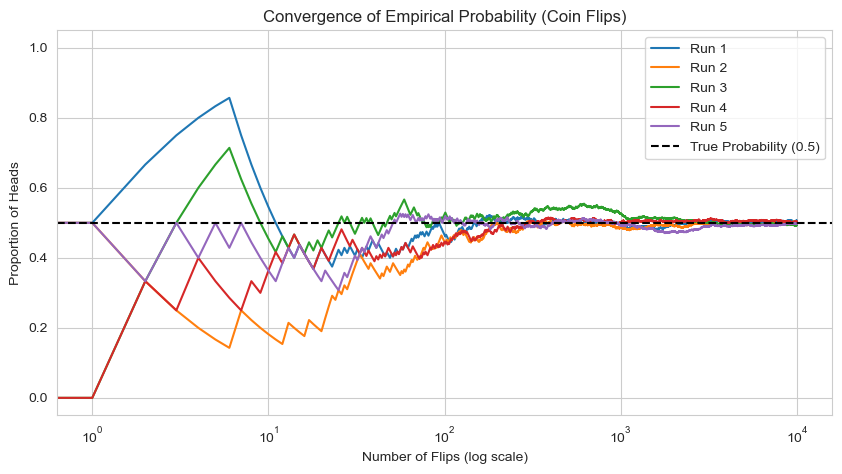

In [16]:
plt.figure(figsize=(10,5))

# Repeat experiment 5 times
for i in range(5):
    flips = np.random.binomial(1, 0.5, size=N)
    running_heads = np.cumsum(flips)
    running_proportion = running_heads / np.arange(1, N+1)
    
    plt.plot(running_proportion, label=f"Run {i+1}")

# Horizontal line at 0.5
plt.axhline(0.5, linestyle="--", color="black", label="True Probability (0.5)")

# Log-scaled x-axis
plt.xscale("log")

plt.title("Convergence of Empirical Probability (Coin Flips)")
plt.xlabel("Number of Flips (log scale)")
plt.ylabel("Proportion of Heads")
plt.legend()

plt.show()

### Task 2: Coin Flips — Observations

- The running proportion of heads fluctuates significantly at the beginning due to randomness.
- As the number of flips increases, the proportion stabilizes and converges toward the true probability of 0.5.

- Across multiple runs, the convergence paths differ early on but become similar as the number of flips increases.

- The running proportion typically stays within ±0.01 of 0.5 after approximately **2,000 to 5,000 flips**.
- This behavior illustrates the Law of Large Numbers, where larger sample sizes lead to more stable and accurate estimates.

In [17]:
# Task 3: Binomial simulation

n_batches = 10000
n = 50
p = 0.03

# Simulate batches (each value = number of defects in a batch)
defects = np.random.binomial(n, p, size=n_batches)

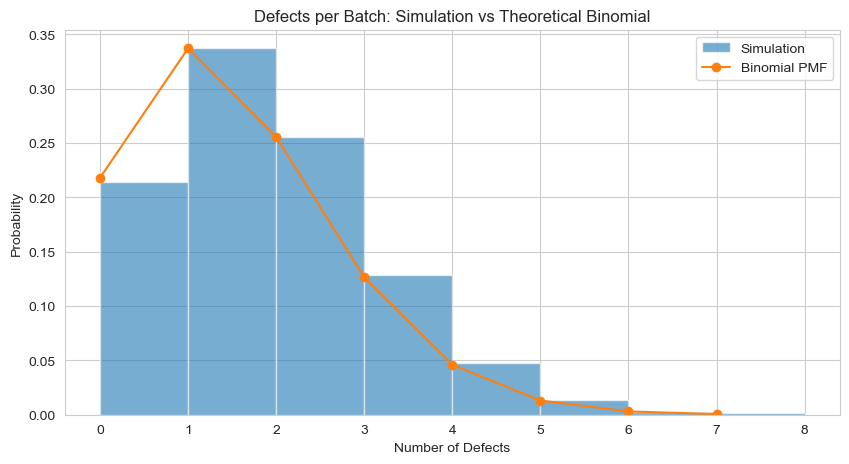

In [18]:
# Histogram
plt.figure(figsize=(10,5))
counts, bins, _ = plt.hist(defects, bins=range(0, max(defects)+2), 
                           density=True, alpha=0.6, label="Simulation")

# Theoretical PMF
k_values = np.arange(0, max(defects)+1)
pmf = stats.binom.pmf(k_values, n, p)

# Overlay PMF
plt.plot(k_values, pmf, marker='o', linestyle='-', label="Binomial PMF")

plt.title("Defects per Batch: Simulation vs Theoretical Binomial")
plt.xlabel("Number of Defects")
plt.ylabel("Probability")
plt.legend()

plt.show()

In [19]:
# Empirical probabilities
p_0_emp = np.mean(defects == 0)
p_3plus_emp = np.mean(defects >= 3)
expected_emp = np.mean(defects)

print("Empirical Estimates:")
print(f"P(0 defects): {p_0_emp:.4f}")
print(f"P(3+ defects): {p_3plus_emp:.4f}")
print(f"Expected defects: {expected_emp:.4f}")

Empirical Estimates:
P(0 defects): 0.2146
P(3+ defects): 0.1926
Expected defects: 1.5115


In [20]:
# Theoretical probabilities
p_0_theory = stats.binom.pmf(0, n, p)
p_3plus_theory = 1 - stats.binom.cdf(2, n, p)
expected_theory = n * p

print("\nTheoretical Values:")
print(f"P(0 defects): {p_0_theory:.4f}")
print(f"P(3+ defects): {p_3plus_theory:.4f}")
print(f"Expected defects: {expected_theory:.4f}")


Theoretical Values:
P(0 defects): 0.2181
P(3+ defects): 0.1892
Expected defects: 1.5000


### Task 3: Binomial Simulation — Observations

- The empirical estimates are very close to the theoretical binomial values.
- This confirms that the simulation accurately reflects the underlying probability model.

- The histogram closely matches the shape of the theoretical PMF, with most batches having 0–2 defects.
- The probability of 3 or more defects is relatively low, as expected with a 3% defect rate.

- The expected number of defects per batch is approximately **n × p = 50 × 0.03 = 1.5**, which aligns with both simulation and theory.

- With 10,000 batches, the estimates are very stable and closely match theoretical values.
- Using only 1,000 batches would produce more variability and less precise estimates.

- This demonstrates that larger sample sizes lead to more accurate approximations of theoretical probabilities.